In [36]:
import numpy as np
import pandas as pd
import matplotlib as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('stores_sales_forecasting.csv', encoding='ISO-8859-1')
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
3,6,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-FU-10001487,Furniture,Furnishings,Eldon Expressions Wood and Plastic Desk Access...,48.8600,7,0.00,14.1694
4,11,CA-2014-115812,6/9/2014,6/14/2014,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,90032,West,FUR-TA-10001539,Furniture,Tables,Chromcraft Rectangular Conference Tables,1706.1840,9,0.20,85.3092


In [3]:
df.groupby(["Customer ID", "Product ID"]).count()

Row ID  Order ID  Order Date  Ship Date  \
Customer ID Product ID                                                 
AA-10315    FUR-FU-10002456       1         1           1          1   
AA-10375    FUR-FU-10003347       1         1           1          1   
AA-10480    FUR-FU-10001473       1         1           1          1   
            FUR-TA-10004147       1         1           1          1   
AA-10645    FUR-BO-10001811       1         1           1          1   
...                             ...       ...         ...        ...   
ZC-21910    FUR-FU-10004006       1         1           1          1   
            FUR-TA-10002903       1         1           1          1   
            FUR-TA-10003954       1         1           1          1   
ZD-21925    FUR-FU-10003799       1         1           1          1   
            FUR-FU-10004270       1         1           1          1   

                             Ship Mode  Customer Name  Segment  Country  City  \
Customer ID Product ID                                                          
AA-10315    FUR-FU-10002456          1              1        1        1     1   
AA-10375    FUR-FU-10003347          1              1        1        1     1   
AA-10480    FUR-FU-10001473          1              1        1        1     1   
            FUR-TA-10004147          1              1        1        1     1   
AA-10645    FUR-BO-10001811          1              1        1        1     1   
...                                ...            ...      ...      ...   ...   
ZC-21910    FUR-FU-10004006          1              1        1        1     1   
            FUR-TA-10002903          1              1        1        1     1   
            FUR-TA-10003954          1              1        1        1     1   
ZD-21925    FUR-FU-10003799          1              1        1        1     1   
            FUR-FU-10004270          1              1        1        1     1   

                             State  Postal Code  Region  Category  \
Customer ID Product ID                                              
AA-10315    FUR-FU-10002456      1            1       1         1   
AA-10375    FUR-FU-10003347      1            1       1         1   
AA-10480    FUR-FU-10001473      1            1       1         1   
            FUR-TA-10004147      1            1       1         1   
AA-10645    FUR-BO-10001811      1            1       1         1   
...                            ...          ...     ...       ...   
ZC-21910    FUR-FU-10004006      1            1       1         1   
            FUR-TA-10002903      1            1       1         1   
            FUR-TA-10003954      1            1       1         1   
ZD-21925    FUR-FU-10003799      1            1       1         1   
            FUR-FU-10004270      1            1       1         1   

                             Sub-Category  Product Name  Sales  Quantity  \
Customer ID Product ID                                                     
AA-10315    FUR-FU-10002456             1             1      1         1   
AA-10375    FUR-FU-10003347             1             1      1         1   
AA-10480    FUR-FU-10001473             1             1      1         1   
            FUR-TA-10004147             1             1      1         1   
AA-10645    FUR-BO-10001811             1             1      1         1   
...                                   ...           ...    ...       ...   
ZC-21910    FUR-FU-10004006             1             1      1         1   
            FUR-TA-10002903             1             1      1         1   
            FUR-TA-10003954             1             1      1         1   
ZD-21925    FUR-FU-10003799             1             1      1         1   
            FUR-FU-10004270             1             1      1         1   

                             Discount  Profit  
Customer ID Product ID                         
AA-10315    FUR-FU-10002456         1       1  
AA-1037

In [4]:
# Load data
data = df
# Convert date columns to datetime
data['Order Date'] = pd.to_datetime(data['Order Date'])
data['Ship Date'] = pd.to_datetime(data['Ship Date'])

In [5]:
# Calculate the days since the first order for each customer
df['Days Since First Order'] = df.groupby('Customer ID')['Order Date'].transform(lambda x: (x - x.min()).dt.days)

In [6]:
multiple_product_customers = df.groupby('Customer ID')['Product ID'].nunique()

# Filter customers who have purchased more than one product
multiple_product_customers = multiple_product_customers[multiple_product_customers > 1]

print(len(multiple_product_customers.index.tolist()))

547


In [7]:
# Preprocessing and Feature Engineering
def preprocess_data(data):
    # Create lag features for 'Sales' and 'Profit'
    data['lag_sales_1'] = data.groupby('Customer ID')['Sales'].shift(1)
    data['lag_profit_1'] = data.groupby('Customer ID')['Profit'].shift(1)
    
    # Create rolling statistics for 'Sales' and 'Profit'
    data['rolling_sales_mean_3'] = data.groupby('Customer ID')['Sales'].rolling(window=3).mean().reset_index(0, drop=True)
    data['rolling_profit_mean_3'] = data.groupby('Customer ID')['Profit'].rolling(window=3).mean().reset_index(0, drop=True)

    # Create cohort feature: Months since the first order for each customer
    #data['cohort'] = (data['Order Date'] - data.groupby('Customer ID')['Order Date'].transform('min')).dt.days
    data['cohort'] = (data['Order Date'].dt.to_period('M') - data.groupby('Customer ID')['Order Date'].transform('min').dt.to_period('M')).apply(lambda x: x.n)


    # Create target label 'churn': Mark customers who haven't made an order in the last 90 days as churned
    latest_order_date = data['Order Date'].max()
    data['churn'] = np.where((latest_order_date - data.groupby('Customer ID')['Order Date'].transform('max')).dt.days > 90, 1, 0)

    return data

data_processed_prenan = preprocess_data(df)

data_processed = data_processed_prenan.dropna() # Drop rows with missing values caused by shifting or rolling

In [8]:
data_processed.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Days Since First Order,lag_sales_1,lag_profit_1,rolling_sales_mean_3,rolling_profit_mean_3,cohort,churn
20,79,US-2014-147606,2014-11-26,2014-12-01,Second Class,JE-15745,Joel Eaton,Consumer,United States,Houston,...,5,0.6,-14.4750,0,97.0400,1.2130,316.092000,-42.551067,0,0
39,178,US-2015-101511,2015-11-21,2015-11-23,Second Class,JE-15745,Joel Eaton,Consumer,United States,Newark,...,7,0.3,-11.3372,360,19.3000,-14.4750,171.047333,-8.199733,12,0
51,235,US-2017-100930,2017-04-07,2017-04-12,Standard Class,CS-12400,Christopher Schild,Home Office,United States,Tampa,...,3,0.2,0.0000,0,620.6145,-248.2458,370.848833,-116.764600,0,1
54,242,CA-2016-157749,2016-06-04,2016-06-09,Second Class,KL-16645,Ken Lonsdale,Consumer,United States,Chicago,...,5,0.5,-120.5130,680,11.6880,-4.6752,202.864333,-160.638733,23,1
55,243,CA-2016-157749,2016-06-04,2016-06-09,Second Class,KL-16645,Ken Lonsdale,Consumer,United States,Chicago,...,3,0.6,-2.8308,680,177.2250,-120.5130,64.319000,-42.673000,23,1


In [9]:
#data_processed.to_csv('data.csv', index = False)

In [10]:
columns_to_drop = ['Row ID', 'Order ID', 'Order Date', 'Ship Date', 
                   'Customer ID', 'Customer Name', 'Product ID', 
                   'Product Name', 'Postal Code', 'City', 'State']

### Reason for drop:
Unique Identifiers: Drop these, as they don’t provide predictive power for churn.
Row ID
Order ID
Customer ID
Product ID

Irrelevant to Customer Churn:
Order Date and Ship Date: Dates might not directly influence churn unless you extract meaningful patterns (e.g., frequency of orders over time).
Customer Name: This is purely identifying information.
Product Name: Generally too specific and unlikely to influence churn.

Address-Related Fields:
Postal Code: This is often too granular.
City and State: These may not add much value if you already have broader location information like Country and Region.

In [11]:
data_processed = data_processed.drop(columns=columns_to_drop, axis = 1)

In [12]:
data_processed.head()

,Ship Mode,Segment,Country,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit,Days Since First Order,lag_sales_1,lag_profit_1,rolling_sales_mean_3,rolling_profit_mean_3,cohort,churn
20,Second Class,Consumer,United States,Central,Furniture,Furnishings,19.300,5,0.6,-14.4750,0,97.0400,1.2130,316.092000,-42.551067,0,0
39,Second Class,Consumer,United States,East,Furniture,Chairs,396.802,7,0.3,-11.3372,360,19.3000,-14.4750,171.047333,-8.199733,12,0
51,Standard Class,Home Office,United States,South,Furniture,Furnishings,258.072,3,0.2,0.0000,0,620.6145,-248.2458,370.848833,-116.764600,0,1
54,Second Class,Consumer,United States,Central,Furniture,Tables,177.225,5,0.5,-120.5130,680,11.6880,-4.6752,202.864333,-160.638733,23,1
55,Second Class,Consumer,United States,Central,Furniture,Furnishings,4.044,3,0.6,-2.8308,680,177.2250,-120.5130,64.319000,-42.673000,23,1


In [13]:
#categorical Columns to be encoded
categorical_columns = ['Ship Mode', 'Segment', 'Country', 'Region', 'Category', 'Sub-Category']

In [14]:
data_processed = pd.get_dummies(data_processed, columns=categorical_columns, drop_first=True)

In [15]:
data_processed = data_processed.astype(int)

In [16]:
data_processed.head()

,Sales,Quantity,Discount,Profit,Days Since First Order,lag_sales_1,lag_profit_1,rolling_sales_mean_3,rolling_profit_mean_3,cohort,...,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Sub-Category_Chairs,Sub-Category_Furnishings,Sub-Category_Tables
20,19,5,0,-14,0,97,1,316,-42,0,...,1,0,0,0,0,0,0,0,1,0
39,396,7,0,-11,360,19,-14,171,-8,12,...,1,0,0,0,1,0,0,1,0,0
51,258,3,0,0,0,620,-248,370,-116,0,...,0,1,0,1,0,1,0,0,1,0
54,177,5,0,-120,680,11,-4,202,-160,23,...,1,0,0,0,0,0,0,0,0,1
55,4,3,0,-2,680,177,-120,64,-42,23,...,1,0,0,0,0,0,0,0,1,0


In [17]:
data_processed.groupby(['churn']).count()/data_processed.shape[0] * 100

,Sales,Quantity,Discount,Profit,Days Since First Order,lag_sales_1,lag_profit_1,rolling_sales_mean_3,rolling_profit_mean_3,cohort,...,Ship Mode_Second Class,Ship Mode_Standard Class,Segment_Corporate,Segment_Home Office,Region_East,Region_South,Region_West,Sub-Category_Chairs,Sub-Category_Furnishings,Sub-Category_Tables
churn,,,,,,,,,,,,,,,,,,,,,
0,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,...,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582,37.485582
1,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,...,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418,62.514418


In [18]:
#Traget
y = data_processed['churn']

In [19]:
#Features
X = data_processed.drop(['churn'], axis = 1)

In [20]:
#Split/Train 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2, random_state = 42)

In [21]:
knn = KNeighborsClassifier()

In [22]:
parameters = {"n_neighbors": np.arange(1, 100)}

In [23]:
knnclassifier = GridSearchCV(knn, parameters, cv = 10)

In [24]:
knnclassifier.fit(X_train, y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'n_neighbors': array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34,
       35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51,
       52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68,
       69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85,
       86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])})

In [39]:
y_pred = knnclassifier.predict(X_test)

### Evaluate

In [45]:
print(knnclassifier.best_score_)

0.6607843137254903


In [47]:
results = pd.DataFrame(knnclassifier.cv_results_)

In [48]:
results.head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.005966,0.005632,0.009642,0.009185,1,{'n_neighbors': 1},0.611111,0.500000,0.611111,0.388889,0.529412,0.588235,0.647059,0.470588,0.882353,0.411765,0.564052,0.134585,96
1,0.003398,0.003469,0.009895,0.005058,2,{'n_neighbors': 2},0.388889,0.500000,0.500000,0.222222,0.588235,0.588235,0.470588,0.529412,0.705882,0.294118,0.478758,0.136774,99
2,0.004000,0.004208,0.009794,0.005877,3,{'n_neighbors': 3},0.555556,0.666667,0.666667,0.388889,0.588235,0.588235,0.529412,0.588235,0.705882,0.588235,0.586601,0.083895,91
3,0.005859,0.006732,0.005189,0.005143,4,{'n_neighbors': 4},0.555556,0.555556,0.722222,0.333333,0.647059,0.529412,0.470588,0.470588,0.647059,0.470588,0.540196,0.106719,97
4,0.005575,0.005317,0.008076,0.006274,5,{'n_neighbors': 5},0.611111,0.722222,0.722222,0.388889,0.705882,0.588235,0.588235,0.529412,0.529412,0.529412,0.591503,0.100141,89


### Mean_test_score Graph
The graph below is visualization of how the model's performance changes as you adjust certain hyperparameters during the process of hyperparameter tuning. We see that our model preforms best at 40, meaning 40 represents the specific value of the hyperparameter that gave the highest mean test score across all the cross-validation folds.Then k = 40 might be the value of k that gives the highest classification accuracy

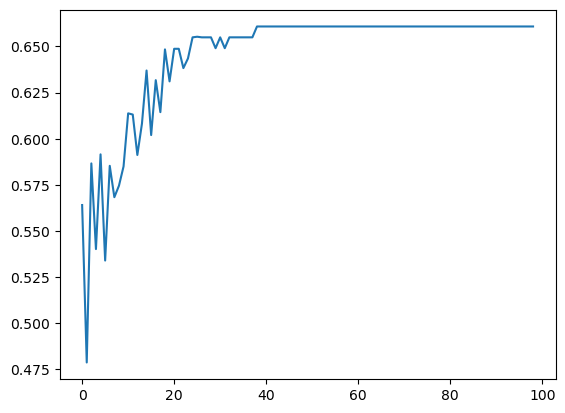

In [50]:
plt.plot(results["mean_test_score"])

In [40]:
#Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy}')

Accuracy: 0.6609195402298851


In [41]:
precision = precision_score(y_test, y_pred)
print(f"Precision: {precision}")

Precision: 0.6609195402298851


In [42]:
recall = recall_score(y_test, y_pred)
print(f"Recall: {recall}")

Recall: 1.0


In [43]:
f1 = f1_score(y_test, y_pred)
print(f"F1 Score: {f1}")

F1 Score: 0.7958477508650519
